In [1]:
!pip install scikit-image pydicom opencv-python

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from skimage.transform import resize
import matplotlib.pyplot as plt
import pydicom
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Dataset paths (adjust as needed)
dataset_path = "../input/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/"
train_images_dir = os.path.join(dataset_path, "stage_2_train/")
train_csv = os.path.join(dataset_path, "stage_2_train.csv")

# Load and preprocess train.csv
df = pd.read_csv(train_csv)
# Create 'id' and 'subtype' columns: e.g., "ID_12345_epidural" -> id: "ID_12345", subtype: "epidural"
df['id'] = df['ID'].apply(lambda st: "ID_" + st.split('_')[1])
df['subtype'] = df['ID'].apply(lambda st: st.split('_')[2])
df = df[["id", "subtype", "Label"]]

# Remove duplicates and fill missing values
df = df.drop_duplicates(subset=['id', 'subtype'])
df['Label'] = df['Label'].fillna(0)

# Pivot data so each row is one image and columns are subtypes
df_pivot = df.pivot(index='id', columns='subtype', values='Label').reset_index()
# Add file paths
df_pivot['file_path'] = df_pivot['id'].apply(lambda x: os.path.join(train_images_dir, f"{x}.dcm"))

df_subset = df_pivot.sample(n=2000, random_state=42)
print(f"Using {len(df_subset)} samples for training.")

# Preprocess DICOM images function
def preprocess_dicom(file_path, label, target_size=(224, 224)):
    try:
        dicom = pydicom.dcmread(file_path)
        img = dicom.pixel_array
        img = resize(img, target_size, mode="constant", anti_aliasing=True)
        img = np.expand_dims(img, axis=-1)  # add channel dimension
        img = np.repeat(img, 3, axis=-1)    # convert to 3-channel RGB
        img = img / np.max(img) if np.max(img) > 0 else img
        return img, label
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None

images, labels = [], []
for _, row in df_subset.iterrows():
    img, lbl = preprocess_dicom(row['file_path'],
                                row[["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]].values)
    if img is not None:
        images.append(img)
        labels.append(lbl)

images = np.array(images)
labels = np.array(labels)
print("Preprocessed Images shape:", images.shape)
print("Preprocessed Labels shape:", labels.shape)

# Split data
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)

y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)

# Define VGG16 model
def create_vgg16_model(input_shape=(224, 224, 3), num_classes=6):
    base_model = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="sigmoid")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

vgg16_model = create_vgg16_model()

vgg16_model.save('vgg16_model.h5')

vgg16_history = vgg16_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=3, batch_size=32)

# Check data shapes and types
print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("y_train shape:", y_train.shape, "dtype:", y_train.dtype)
print("X_val shape:", X_val.shape, "dtype:", X_val.dtype)
print("y_val shape:", y_val.shape, "dtype:", y_val.dtype)

# Predict on validation data
vgg16_y_pred = vgg16_model.predict(X_val)
vgg16_y_pred_binary = (vgg16_y_pred > 0.5).astype(int)

Using 2000 samples for training.
Preprocessed Images shape: (2000, 224, 224, 3)
Preprocessed Labels shape: (2000, 6)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 591s 12s/step - accuracy: 0.0811 - loss: 0.6818 - val_accuracy: 0.0425 - val_loss: 0.4545
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 532s 11s/step - accuracy: 0.0817 - loss: 0.4449 - val_accuracy: 0.0350 - val_loss: 0.3235
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 567s 11s/step - accuracy: 0.1297 - loss: 0.3262 - val_accuracy: 0.0425 - val_loss: 0.2665
X_train shape: (1600, 224, 224, 3) dtype: float64
y_train shape: (1600, 6) dtype: float32
X_val shape: (400, 224, 224, 3) dtype: float64
y_val shape: (400, 6) dtype: float32
13/13 ━━━━━━━━━━━━━━━━━━━━ 104s 8s/step


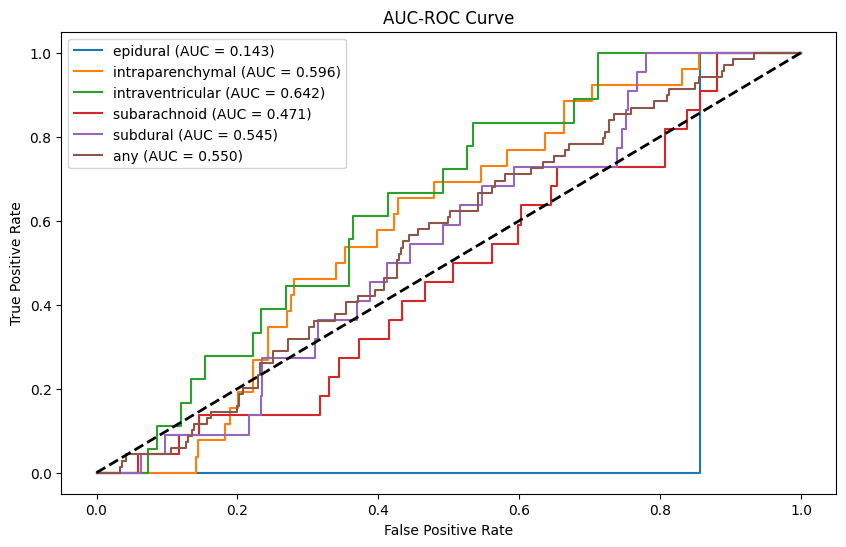

In [2]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 6))

for i, label in enumerate(["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]):
    fpr, tpr, _ = roc_curve(y_val[:, i], vgg16_y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve")
plt.legend()
plt.show()

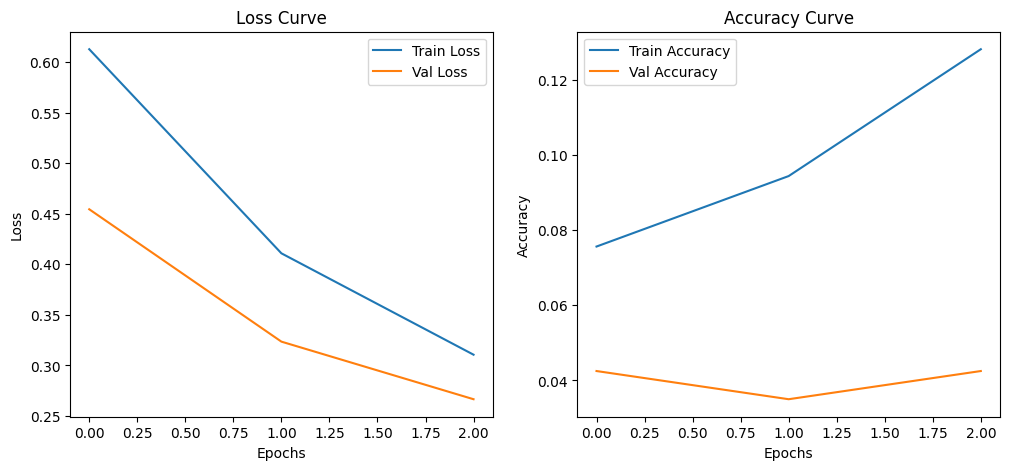

In [3]:
# Plot training & validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(vgg16_history.history['loss'], label='Train Loss')
plt.plot(vgg16_history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(vgg16_history.history['accuracy'], label='Train Accuracy')
plt.plot(vgg16_history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Calculate evaluation metrics
vgg16_f1 = f1_score(y_val, vgg16_y_pred_binary, average='weighted', zero_division=1)
vgg16_precision = precision_score(y_val, vgg16_y_pred_binary, average='weighted', zero_division=1)
vgg16_recall = recall_score(y_val, vgg16_y_pred_binary, average='weighted', zero_division=1)

# Sensitivity (Recall per class) with safe division
vgg16_conf_matrix = confusion_matrix(y_val.argmax(axis=1), vgg16_y_pred_binary.argmax(axis=1))
vgg16_sensitivity = np.divide(
    np.diag(vgg16_conf_matrix),
    np.sum(vgg16_conf_matrix, axis=1),
    out=np.zeros_like(np.diag(vgg16_conf_matrix), dtype=np.float32),
    where=np.sum(vgg16_conf_matrix, axis=1) != 0
)


# Print metrics
print(f"VGG16 Training Accuracy: {vgg16_history.history['accuracy'][-1]:.4f}")
print(f"VGG16 Training Loss: {vgg16_history.history['loss'][-1]:.4f}")
print(f"VGG16 Validation Accuracy: {vgg16_history.history['val_accuracy'][-1]:.4f}")
print(f"VGG16 Validation Loss: {vgg16_history.history['val_loss'][-1]:.4f}")
print(f"VGG16 F1 Score: {vgg16_f1:.4f}")
print(f"VGG16 Precision: {vgg16_precision:.4f}")
print(f"VGG16 Recall (Sensitivity): {vgg16_recall:.4f}")
print(f"VGG16 Sensitivity (per class): {vgg16_sensitivity}")

VGG16 Training Accuracy: 0.1281
VGG16 Training Loss: 0.3106
VGG16 Validation Accuracy: 0.0425
VGG16 Validation Loss: 0.2665
VGG16 F1 Score: 0.0000
VGG16 Precision: 1.0000
VGG16 Recall (Sensitivity): 0.0000
VGG16 Sensitivity (per class): [1. 0. 0. 0. 0.]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
epidural: No Hemorrhage (0.50)
intraparenchymal: Hemorrhage Detected (0.59)
intraventricular: No Hemorrhage (0.23)
subarachnoid: Hemorrhage Detected (0.59)
subdural: Hemorrhage Detected (0.73)
any: No Hemorrhage (0.37)


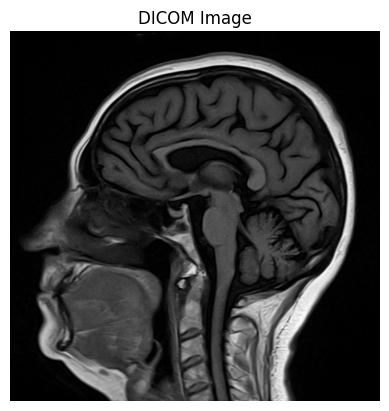

In [10]:
import numpy as np
import pydicom
import os
import tensorflow as tf
from skimage.transform import resize
import matplotlib.pyplot as plt

# Load trained model
model = tf.keras.models.load_model("vgg16_model.h5")

# Define image path
image_path = "/kaggle/input/images/1-1.dcm"

def preprocess_dicom(file_path, target_size=(224, 224)):
    try:
        dicom = pydicom.dcmread(file_path)
        img = dicom.pixel_array
        img = resize(img, target_size, mode="constant", anti_aliasing=True)
        img = np.expand_dims(img, axis=-1)  # Add channel dimension
        img = np.repeat(img, 3, axis=-1)    # Convert grayscale to RGB
        img = img / np.max(img) if np.max(img) > 0 else img  # Normalize
        return np.expand_dims(img, axis=0)  # Add batch dimension
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Preprocess the image
image = preprocess_dicom(image_path)
if image is not None:
    # Predict
    predictions = model.predict(image)[0]
    
    # Define hemorrhage subtypes
    hemorrhage_types = ["epidural", "intraparenchymal", "intraventricular", "subarachnoid", "subdural", "any"]
    
    # Print predictions
    for hemorrhage, prob in zip(hemorrhage_types, predictions):
        print(f"{hemorrhage}: {'Hemorrhage Detected' if prob > 0.5 else 'No Hemorrhage'} ({prob:.2f})")
    
    # Display image
    dicom = pydicom.dcmread(image_path)
    plt.imshow(dicom.pixel_array, cmap='gray')
    plt.title("DICOM Image")
    plt.axis("off")
    plt.show()
else:
    print("Failed to process the image.")